In [62]:
import pandas as pd
from glob import glob
import os
from tqdm import tqdm
from scipy.stats import iqr
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',500)

## Charged

In [25]:
!cat /projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/charged/report.txt


+--------------------------------------------------+---------------+
|              📊 СТАТИСТИКА PIPELINE              |               |
+--------------------------------------------------+---------------+
| Всего задач в samplesheet                        | 80           |
| Уникальных моделей                               | 80           |
| Успешно построено                                | 80           |
| Процент успеха (модели)                          | 100.0%       |
| Уникальных тестирований                          | 0            |
| Успешно проведено                                | 0            |
| Процент успеха (тесты)                           | 0%           |
+--------------------------------------------------+---------------+
Дата: 2026-03-30 20:01:01


In [35]:
charged_samplesheet = pd.read_csv("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/charged/output_samplesheet.csv")
charged_samplesheet.head()

,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,4,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,d7f616b6ffb61cbf06fe46e752b57e28,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,6,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,773315be5594eecb55e31584c2229aeb,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,7,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c29c8d5bb62ae7bd68db4e5e7daed629,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST


In [36]:
charged_logs = glob("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/charged/train_results/*.csv")
len(charged_logs)

80

In [37]:
charged_samplesheet["basename"] = charged_samplesheet["train_file"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
charged_samplesheet[["Structure", "Activity", "Species"]] = charged_samplesheet["basename"].str.split("_",expand=True)
charged_samplesheet.head()

,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,4,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,d7f616b6ffb61cbf06fe46e752b57e28,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,6,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,773315be5594eecb55e31584c2229aeb,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,7,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c29c8d5bb62ae7bd68db4e5e7daed629,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human


In [38]:
metrics_tbls = []
for i in tqdm(charged_samplesheet.index):
    metrics_path = os.path.join("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/charged/train_results",f"{charged_samplesheet.loc[i,'train_id']}.csv")
    if os.path.exists(metrics_path):
        metrics = pd.read_csv(metrics_path, sep = ";")
        metrics['train_id'] = charged_samplesheet.loc[i,'train_id']
        metrics_tbls.append(metrics)
total_metrics = pd.concat(metrics_tbls, ignore_index=True)
ch_samplesheet_metrics = pd.merge(charged_samplesheet, total_metrics, on = 'train_id')
ch_samplesheet_metrics['type'] = 'charged'
print(ch_samplesheet_metrics.shape)
ch_samplesheet_metrics.head()

100%|██████████| 80/80 [00:00<00:00, 503.02it/s]


(11253, 35)


,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species,No,Check,N,IAP,5-F CV,MAP,NN,NP,Prec.,TP,TN,FP,FN,Activity Type,sample_size,Sens.,Spec.,MCC,F1,type
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,1,Ok,11,0.8261,0.7141,0.6437,56391,11,0.0004,7,36297,20094,4,AAFKRSCLK,56402,0.636364,0.643667,0.008165,0.000799,charged
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,2,Ok,11,0.8354,0.6784,0.6009,56391,11,0.0003,7,33884,22507,4,AAGIGILTV,56402,0.636364,0.600876,0.006765,0.000600,charged
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,3,Ok,14,0.7449,0.7082,0.6456,56388,14,0.0005,9,36404,19984,5,AIFYLITPV,56402,0.642857,0.645598,0.009499,0.000999,charged
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,4,Ok,4,0.9438,0.9476,0.6968,56398,4,0.0002,3,39297,17101,1,AIILASFSA,56402,0.750000,0.696780,0.008185,0.000400,charged
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,5,Ok,3,0.9687,0.9732,0.7435,56399,3,0.0002,2,41934,14465,1,AIMDKNIIL,56402,0.666667,0.743524,0.006850,0.000400,charged


## Neutral

In [39]:
!cat /projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/report.txt


+--------------------------------------------------+---------------+
|              📊 СТАТИСТИКА PIPELINE              |               |
+--------------------------------------------------+---------------+
| Всего задач в samplesheet                        | 80           |
| Уникальных моделей                               | 80           |
| Успешно построено                                | 80           |
| Процент успеха (модели)                          | 100.0%       |
| Уникальных тестирований                          | 0            |
| Успешно проведено                                | 0            |
| Процент успеха (тесты)                           | 0%           |
+--------------------------------------------------+---------------+
Дата: 2026-03-30 20:38:31


In [40]:
neutral_samplesheet = pd.read_csv("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/output_samplesheet.csv")
neutral_samplesheet.head()

,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,4,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,d7f616b6ffb61cbf06fe46e752b57e28,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,6,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,773315be5594eecb55e31584c2229aeb,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,7,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c29c8d5bb62ae7bd68db4e5e7daed629,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST


In [41]:
neutral_logs = glob("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/train_results/*.csv")
len(neutral_logs)

80

In [42]:
neutral_samplesheet["basename"] = neutral_samplesheet["train_file"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
neutral_samplesheet[["Structure", "Activity", "Species"]] = neutral_samplesheet["basename"].str.split("_",expand=True)
neutral_samplesheet.head()

,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,4,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,d7f616b6ffb61cbf06fe46e752b57e28,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,6,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,773315be5594eecb55e31584c2229aeb,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,7,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c29c8d5bb62ae7bd68db4e5e7daed629,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human


In [43]:
metrics_tbls = []
for i in tqdm(neutral_samplesheet.index):
    metrics_path = os.path.join("/projects/rat_gravitation/anton_disser/TCR-Pred/03_26/results/neutral/train_results",f"{neutral_samplesheet.loc[i,'train_id']}.csv")
    if os.path.exists(metrics_path):
        metrics = pd.read_csv(metrics_path, sep = ";")
        metrics['train_id'] = neutral_samplesheet.loc[i,'train_id']
        metrics_tbls.append(metrics)
total_metrics = pd.concat(metrics_tbls, ignore_index=True)
n_samplesheet_metrics = pd.merge(neutral_samplesheet, total_metrics, on = 'train_id')
n_samplesheet_metrics['type'] = 'neutral'
print(n_samplesheet_metrics.shape)
n_samplesheet_metrics.head()

100%|██████████| 80/80 [00:00<00:00, 403.10it/s]

(11187, 35)


,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species,No,Check,N,IAP,5-F CV,MAP,NN,NP,Prec.,TP,TN,FP,FN,Activity Type,sample_size,Sens.,Spec.,MCC,F1,type
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,1,Ok,11,0.8249,0.8205,0.7068,56391,11,0.0005,8,39855,16536,3,AAFKRSCLK,56402,0.727273,0.706762,0.013312,0.000999,neutral
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,2,Ok,11,0.8319,0.7853,0.6601,56391,11,0.0004,7,37221,19170,4,AAGIGILTV,56402,0.636364,0.660052,0.008738,0.000799,neutral
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,3,Ok,14,0.7462,0.7793,0.6873,56388,14,0.0005,10,38755,17633,4,AIFYLITPV,56402,0.714286,0.687292,0.013644,0.000999,neutral
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,4,Ok,4,0.9429,0.9455,0.6925,56398,4,0.0002,3,39055,17343,1,AIILASFSA,56402,0.750000,0.692489,0.008075,0.000400,neutral
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,5,Ok,3,0.9680,0.9719,0.7371,56399,3,0.0001,2,41572,14827,1,AIMDKNIIL,56402,0.666667,0.737105,0.006689,0.000200,neutral


## Total

In [85]:
total = pd.concat([ch_samplesheet_metrics,n_samplesheet_metrics],ignore_index=True)
total["mna_level"] = total["mna_level"].astype('category')
print(total.shape)
total.head()

(22440, 35)


,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species,No,Check,N,IAP,5-F CV,MAP,NN,NP,Prec.,TP,TN,FP,FN,Activity Type,sample_size,Sens.,Spec.,MCC,F1,type
0,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,1,Ok,11,0.8261,0.7141,0.6437,56391,11,0.0004,7,36297,20094,4,AAFKRSCLK,56402,0.636364,0.643667,0.008165,0.000799,charged
1,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,2,Ok,11,0.8354,0.6784,0.6009,56391,11,0.0003,7,33884,22507,4,AAGIGILTV,56402,0.636364,0.600876,0.006765,0.000600,charged
2,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,3,Ok,14,0.7449,0.7082,0.6456,56388,14,0.0005,9,36404,19984,5,AIFYLITPV,56402,0.642857,0.645598,0.009499,0.000999,charged
3,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,4,Ok,4,0.9438,0.9476,0.6968,56398,4,0.0002,3,39297,17101,1,AIILASFSA,56402,0.750000,0.696780,0.008185,0.000400,charged
4,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,3,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,5c2f3309493725ecea5c0f318d3c015c,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,5,Ok,3,0.9687,0.9732,0.7435,56399,3,0.0002,2,41934,14465,1,AIMDKNIIL,56402,0.666667,0.743524,0.006850,0.000400,charged


In [86]:
grouped = total.groupby(["Structure", 'Activity','Species', 'type','mna_level']).agg(
        n_activity=pd.NamedAgg(column='5-F CV', aggfunc='size'),
        median5CV=pd.NamedAgg(column='5-F CV', aggfunc='median'),
        iqr5CV=pd.NamedAgg(column='5-F CV', aggfunc=iqr),
        mean_precision=pd.NamedAgg(column='Prec.', aggfunc='mean'),
        mean_sensivity=pd.NamedAgg(column='Sens.', aggfunc='mean'),
        mean_specifity=pd.NamedAgg(column='Spec.', aggfunc='mean'),
        sample_size=pd.NamedAgg(column='sample_size', aggfunc='max')
).reset_index()
grouped["Structure"] = grouped["Structure"].replace({'cdr3alpha': "α", 'cdr3beta': "β"})
grouped["Species"] = grouped["Species"].replace({'human': "Человек", 'mouse': "Мышь"})
grouped["Activity"] = grouped["Activity"].replace({'epitope': "Эпитопы", 'mhc': "MHC"})
grouped["type"] = grouped["type"].replace({'charged': "Заряженные", 'neutral': "Нейтральные"})
grouped = grouped.rename(columns = {
"Structure":"Цепь",
"Species":"Вид",
"type":"Тип дескриптора",
"mna_level":"Уровень MNA",
"median5CV":"Медиана ROC AUC",
"iqr5CV":"IQR ROC AUC"
})
grouped.head()

/scratch/ipykernel_3339613/1102259902.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = total.groupby(["Structure", 'Activity','Species', 'type','mna_level']).agg(


,Цепь,Activity,Вид,Тип дескриптора,Уровень MNA,n_activity,Медиана ROC AUC,IQR ROC AUC,mean_precision,mean_sensivity,mean_specifity,sample_size
0,α,Эпитопы,Человек,Заряженные,3,471,0.8108,0.150050,0.002460,0.668706,0.665254,56402
1,α,Эпитопы,Человек,Заряженные,4,519,0.8237,0.186850,0.002209,0.685577,0.687246,71503
2,α,Эпитопы,Человек,Заряженные,5,116,0.8422,0.201175,0.001021,0.714254,0.727724,72429
3,α,Эпитопы,Человек,Заряженные,6,433,0.8638,0.181500,0.003216,0.767493,0.763700,72608
4,α,Эпитопы,Человек,Заряженные,7,299,0.8813,0.209050,0.003462,0.815909,0.800203,72624


In [87]:
epitope = grouped.query("Activity == 'Эпитопы'").rename(columns = {"n_activity":"Кол-во эпитопов"})
epitope.head()

,Цепь,Activity,Вид,Тип дескриптора,Уровень MNA,Кол-во эпитопов,Медиана ROC AUC,IQR ROC AUC,mean_precision,mean_sensivity,mean_specifity,sample_size
0,α,Эпитопы,Человек,Заряженные,3,471,0.8108,0.150050,0.002460,0.668706,0.665254,56402
1,α,Эпитопы,Человек,Заряженные,4,519,0.8237,0.186850,0.002209,0.685577,0.687246,71503
2,α,Эпитопы,Человек,Заряженные,5,116,0.8422,0.201175,0.001021,0.714254,0.727724,72429
3,α,Эпитопы,Человек,Заряженные,6,433,0.8638,0.181500,0.003216,0.767493,0.763700,72608
4,α,Эпитопы,Человек,Заряженные,7,299,0.8813,0.209050,0.003462,0.815909,0.800203,72624


In [90]:
epitope.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 0 to 119
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Цепь             80 non-null     object  
 1   Activity         80 non-null     object  
 2   Вид              80 non-null     object  
 3   Тип дескриптора  80 non-null     object  
 4   Уровень MNA      80 non-null     category
 5   Кол-во эпитопов  80 non-null     int64   
 6   Медиана ROC AUC  80 non-null     float64 
 7   IQR ROC AUC      80 non-null     float64 
 8   mean_precision   80 non-null     float64 
 9   mean_sensivity   80 non-null     float64 
 10  mean_specifity   80 non-null     float64 
 11  sample_size      80 non-null     int64   
dtypes: category(1), float64(5), int64(2), object(4)
memory usage: 7.9+ KB


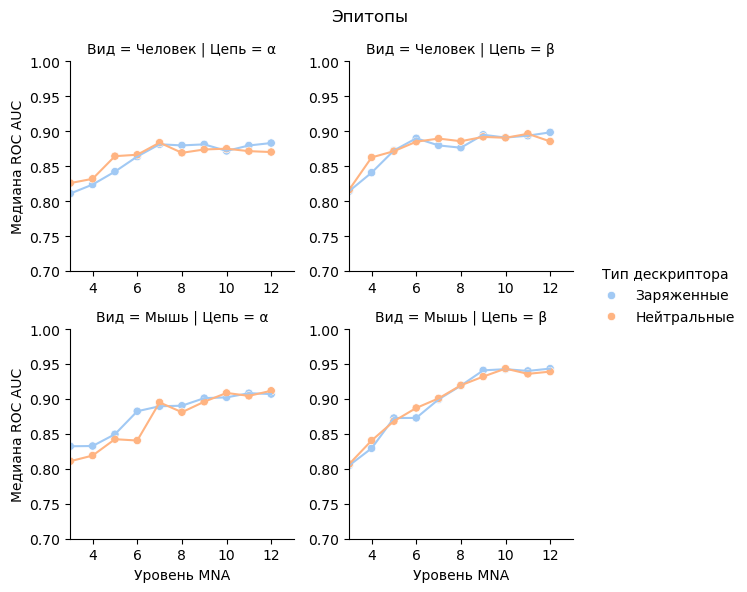

In [89]:
g = sns.FacetGrid(epitope,
                  col="Цепь",
                  row = "Вид", 
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  row_order = ["Человек","Мышь"],
                  col_order = ["α","β"],
                 xlim=(3,13),ylim=(0.7,1))
g.map(sns.lineplot,"Уровень MNA","Медиана ROC AUC","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.map(sns.scatterplot,"Уровень MNA","Медиана ROC AUC","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.add_legend(title = "Тип дескриптора")
g.fig.suptitle(f'Эпитопы')
g.tight_layout()

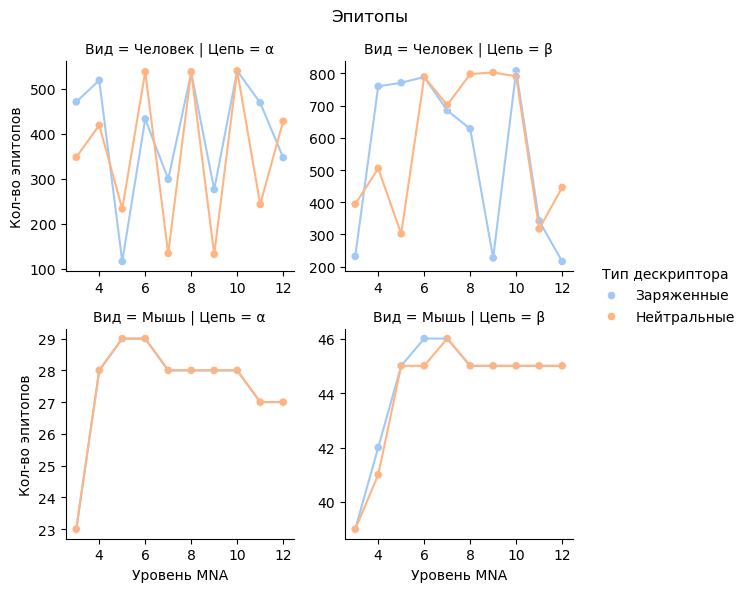

In [70]:
g = sns.FacetGrid(epitope,
                  col="Цепь",
                  row = "Вид", 
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  row_order = ["Человек","Мышь"],
                  col_order = ["α","β"])
g.map(sns.lineplot,"Уровень MNA","Кол-во эпитопов","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.map(sns.scatterplot,"Уровень MNA","Кол-во эпитопов","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.add_legend(title = "Тип дескриптора")
g.fig.suptitle(f'Эпитопы')
g.tight_layout()

In [71]:
epitope.query("`Вид`=='Мышь' and `Цепь`=='α'")

,Цепь,Activity,Вид,Тип дескриптора,Уровень MNA,Кол-во эпитопов,Медиана ROC AUC,IQR ROC AUC,mean_precision,mean_sensivity,mean_specifity,sample_size
20,α,Эпитопы,Мышь,Заряженные,3,23,0.83230,0.168700,0.053617,0.699947,0.696938,2845
21,α,Эпитопы,Мышь,Заряженные,4,28,0.83265,0.159875,0.072071,0.726147,0.724158,3382
22,α,Эпитопы,Мышь,Заряженные,5,29,0.84950,0.129000,0.079110,0.756234,0.739226,3396
23,α,Эпитопы,Мышь,Заряженные,6,29,0.88240,0.093000,0.091717,0.783231,0.775584,3399
24,α,Эпитопы,Мышь,Заряженные,7,28,0.88955,0.082000,0.105557,0.795125,0.795550,3399
25,α,Эпитопы,Мышь,Заряженные,8,28,0.89030,0.093725,0.116907,0.818888,0.813280,3401
26,α,Эпитопы,Мышь,Заряженные,9,28,0.90115,0.075450,0.119825,0.793659,0.802770,3401
27,α,Эпитопы,Мышь,Заряженные,10,28,0.90225,0.073700,0.127275,0.810826,0.818109,3401
28,α,Эпитопы,Мышь,Заряженные,11,27,0.90820,0.065450,0.136837,0.822375,0.829840,3401
29,α,Эпитопы,Мышь,Заряженные,12,27,0.90700,0.101150,0.148848,0.838456,0.833653,3401


In [75]:
total1 = total.query("Structure == 'cdr3alpha' and Species == 'human' and Activity == 'epitope' and mna_level == 5")
total1

,train_file,test_file,model_type,mna_level,ngram_level,class_limit,iap_limit,sdf_train,train_id,sdf_test,test_id,basename,Structure,Activity,Species,No,Check,N,IAP,5-F CV,MAP,NN,NP,Prec.,TP,TN,FP,FN,Activity Type,sample_size,Sens.,Spec.,MCC,F1,type
990,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,1,Ok,11,0.9444,0.8376,0.7358,72418,11,0.0004,8,53282,19136,3,AAFKRSCLK,72429,0.727273,0.735756,0.012939,0.000800,charged
991,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,2,Ok,11,0.9492,0.7476,0.6594,72418,11,0.0003,7,47755,24663,4,AAGIGILTV,72429,0.636364,0.659435,0.007691,0.000600,charged
992,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,3,Ok,7,0.8545,0.8716,0.7381,72422,7,0.0003,5,53456,18966,2,AEMEFCPCC,72429,0.714286,0.738118,0.010115,0.000600,charged
993,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,4,Ok,14,0.8975,0.7756,0.6712,72415,14,0.0004,9,48602,23813,5,AEVQIDRLI,72429,0.642857,0.671159,0.009292,0.000800,charged
994,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,5,Ok,14,0.9197,0.9155,0.7912,72415,14,0.0007,11,57295,15120,3,AIFYLITPV,72429,0.785714,0.791203,0.019728,0.001399,charged
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12248,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,229,Ok,9,0.8595,0.7874,0.6881,72420,9,0.0003,6,49831,22589,3,LLFGMTPCL,72429,0.666667,0.688083,0.008535,0.000600,neutral
12249,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,230,Ok,226,0.7644,0.7390,0.6622,72203,226,0.0061,150,47810,24393,76,LLFGYPVYV,72429,0.663717,0.662161,0.038399,0.012089,neutral
12250,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...,c4817eab89e2be982cfcdae56af7d70d,/projects/rat_gravitation/anton_disser/pass-ne...,NO_TEST,cdr3alpha_epitope_human,cdr3alpha,epitope,human,231,Ok,10,0.9863,0.9871,0.8382,72419,10,0.0007,8,60700,11719,2,LLFLVLIML,72429,0.800000,0.838178,0.020355,0.001399,neutral
12251,/projects/rat_gravitation/anton_disser/TCR-Pre...,/projects/rat_gravitation/anton_disser/TCR-Pre...,mna,5,1,3,0.7,/projects/rat_gravitation/anton_disser/pass-ne...

Нерегулярность , так как на разных  уровнях разное кол-во соединений прошло 5CV

In [77]:
mhc = grouped.query("Activity == 'MHC'").rename(columns = {"n_activity":"Кол-во аллелей"})
mhc.head()

,Цепь,Activity,Вид,Тип дескриптора,Уровень MNA,Кол-во аллелей,Медиана ROC AUC,IQR ROC AUC,mean_precision,mean_sensivity,mean_specifity,sample_size
40,α,MHC,Человек,Заряженные,3,32,0.7901,0.052225,0.002394,0.706135,0.708700,56402
41,α,MHC,Человек,Заряженные,4,33,0.7934,0.090200,0.002070,0.710435,0.716462,71503
42,α,MHC,Человек,Заряженные,5,39,0.8143,0.067800,0.002241,0.725834,0.721158,72429
43,α,MHC,Человек,Заряженные,6,41,0.8079,0.096800,0.005663,0.737333,0.733617,72608
44,α,MHC,Человек,Заряженные,7,43,0.8178,0.106350,0.009514,0.742900,0.747043,72624


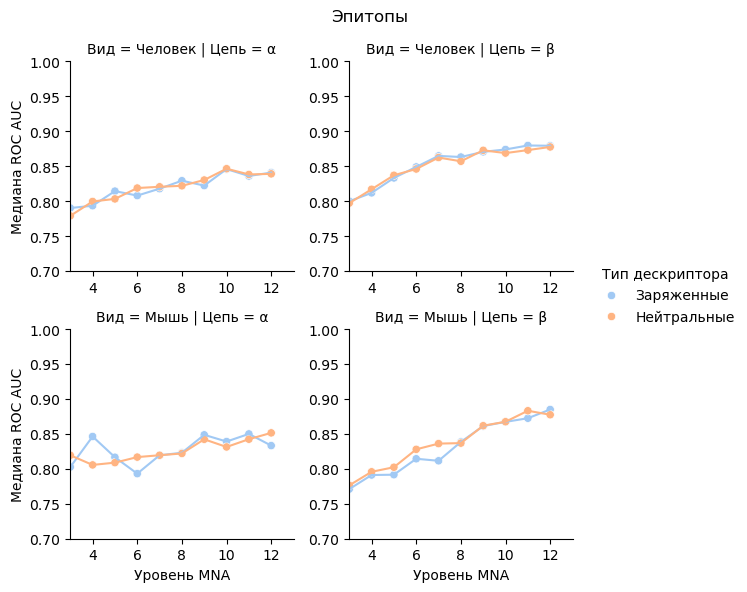

In [91]:
g = sns.FacetGrid(mhc,
                  col="Цепь",
                  row = "Вид", 
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  row_order = ["Человек","Мышь"],
                  col_order = ["α","β"],
                 xlim=(3,13),ylim=(0.7,1))
g.map(sns.lineplot,"Уровень MNA","Медиана ROC AUC","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.map(sns.scatterplot,"Уровень MNA","Медиана ROC AUC","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.add_legend(title = "Тип дескриптора")
g.fig.suptitle(f'Эпитопы')
g.tight_layout()

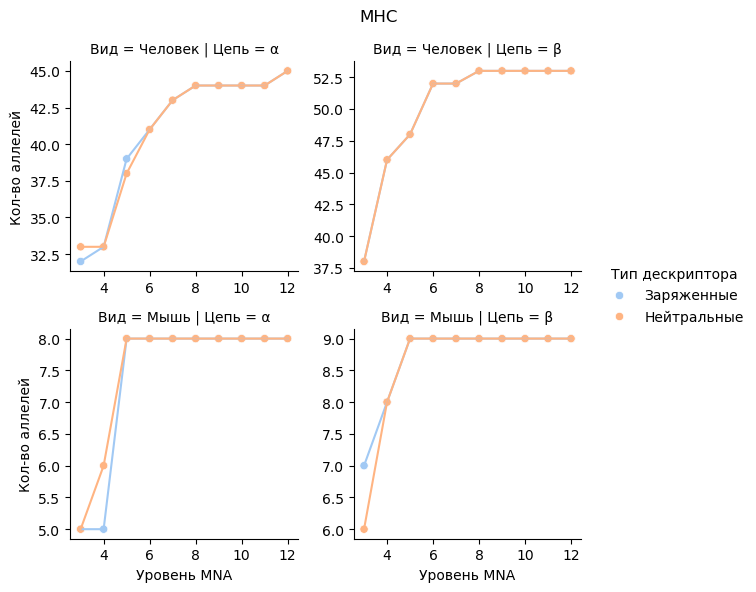

In [93]:
g = sns.FacetGrid(mhc,
                  col="Цепь",
                  row = "Вид", 
                  sharex=False,
                  sharey=False,
                  legend_out = True,
                  row_order = ["Человек","Мышь"],
                  col_order = ["α","β"])
g.map(sns.lineplot,"Уровень MNA","Кол-во аллелей","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.map(sns.scatterplot,"Уровень MNA","Кол-во аллелей","Тип дескриптора",
                  palette=sns.color_palette("pastel")[0:2])
g.add_legend(title = "Тип дескриптора")
g.fig.suptitle(f'MHC')
g.tight_layout()